In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from helper import load_params_csv
from run import run_sim

In [5]:
params = load_params_csv('params/model_params.csv')
params

{'kappa_mu': 0.07,
 'kappa_1': 0.07,
 'kappa_2': 0.07,
 'mu_hat': 0.015,
 'sigma_hat': 0.05,
 'eta_0': 0.03,
 'sigma_0': 0.1,
 'mu_0': 0.11,
 'R_0': 356.0,
 'rho12': 0.0,
 'rho13': 0.0,
 'rho23': 0.0,
 'F_0': 100.0,
 'theta': 0.6,
 'r0': 0.06,
 'xi': 0.5,
 'theta_r': 0.04,
 'omega': 0.1}

In [7]:
T = 25
n_steps = 100
alpha = 0.6
entry_mult = 25
output = run_sim(
    params,
    n_steps=n_steps,
    n_paths=1_000,
    T = T,
    alpha=alpha,
    entry_mult=entry_mult,
    seed=99,
    stochastic_ir = True,
    return_all = True
)

In [9]:
output.keys()

dict_keys(['R', 'C', 'Y', 'mus', 'sigmas', 'etas', 'dW', 'dt', 'D', 'I', 'P', 'defaulted', 'CF', 'r'])

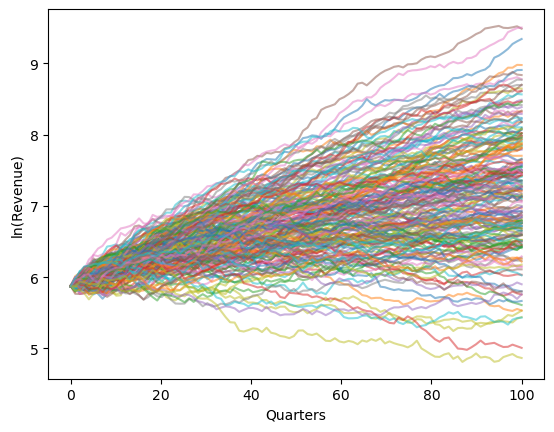

In [11]:
fig, ax = plt.subplots()

grid = np.linspace(0, T * 4, n_steps)

for path in output['R'][:200]:
    ax.plot(grid, np.log(path), alpha=.5)
ax.set_xlabel('Quarters')
ax.set_ylabel('ln(Revenue)')

plt.show()

/var/folders/8z/6vyvm84j61z3zv4ynthd44m00000gn/T/ipykernel_28748/977870072.py:6: RuntimeWarning: invalid value encountered in log
  ax.plot(grid, np.log(path), alpha=.5)


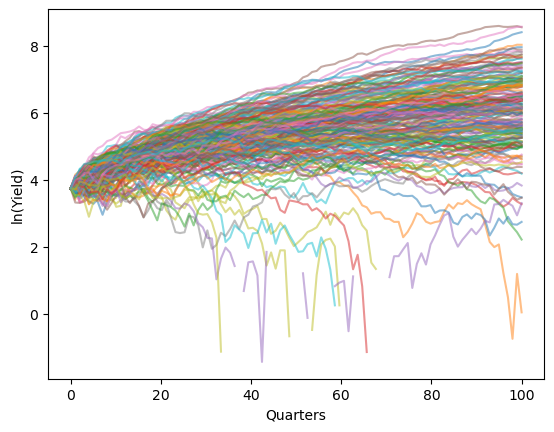

In [13]:
fig, ax = plt.subplots()

grid = np.linspace(0, T * 4, n_steps)

for path in output['Y'][:200]:
    ax.plot(grid, np.log(path), alpha=.5)
ax.set_xlabel('Quarters')
ax.set_ylabel('ln(Yield)')

plt.show()

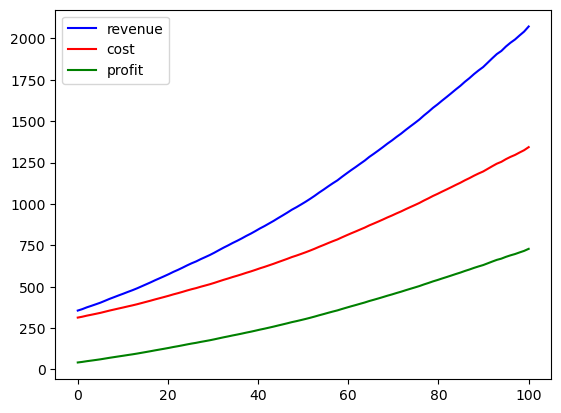

In [15]:
R_mean = output['R'].mean(axis=0)
C_mean = output['C'].mean(axis=0)
Y_mean = output['Y'].mean(axis=0)

fig, ax = plt.subplots()
ax.plot(grid, R_mean, color='blue', label='revenue')
ax.plot(grid, C_mean, color='red', label='cost')
ax.plot(grid, Y_mean, color='green', label='profit')
ax.legend()
    
plt.show()

In [17]:
default_rate = output['defaulted'][:, -1].mean()
default_rate

0.313

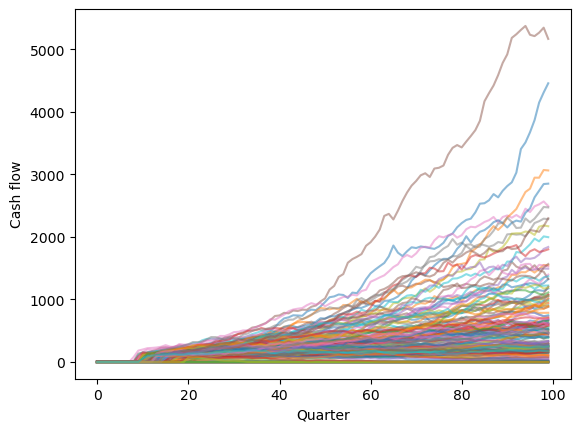

In [19]:
fig, ax = plt.subplots()
for path in output['CF'][:200]:
    ax.plot(path, alpha=0.5)
ax.set_xlabel("Quarter")
ax.set_ylabel("Cash flow")
plt.show()

/var/folders/8z/6vyvm84j61z3zv4ynthd44m00000gn/T/ipykernel_28748/176235230.py:3: RuntimeWarning: divide by zero encountered in log
  ax.plot(np.log(path), alpha=0.5)


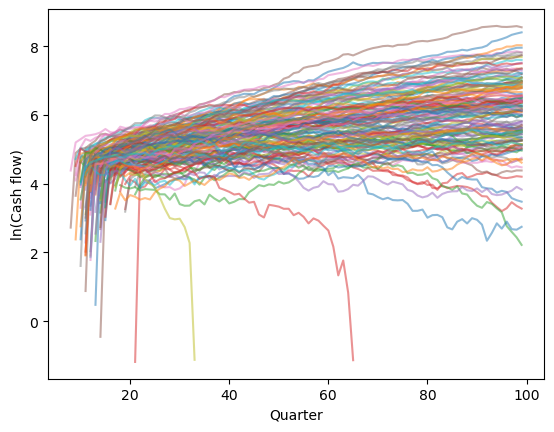

In [21]:
fig, ax = plt.subplots()
for path in output['CF'][:200]:
    ax.plot(np.log(path), alpha=0.5)
ax.set_xlabel("Quarter")
ax.set_ylabel("ln(Cash flow)")
plt.show()

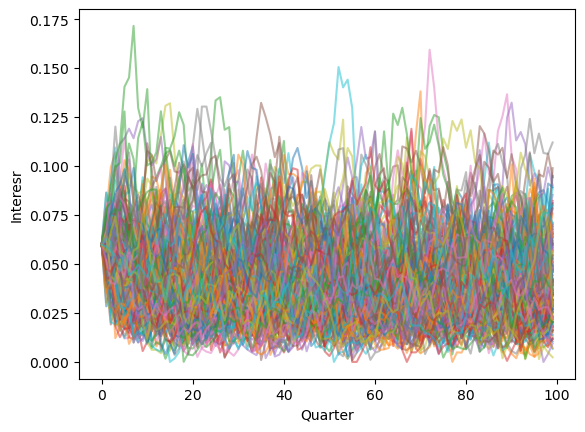

In [23]:
fig, ax = plt.subplots()
for path in output['r'][:200]:
    ax.plot(path, alpha=0.5)
ax.set_xlabel("Quarter")
ax.set_ylabel("Interesr")
plt.show()